# Using Multi-layer Preceptron for binary prediction between pre-term and term neonatal brain using MRI features in pkl form.

Key steps:
1) Data processing + splitting data into training and testing set
2) Neural Network pipeline setup
3) Training and Validation pipeline setup
4) Plotting Validation loss and Accuracy.



Importing all the necessary modules

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


Importing the file that we need

In [2]:
filepath = "prem_vs_termwrois.pkl"
df = pd.read_pickle(filepath)
data = df.values[:,:-2]
y = df.values[:,-1]
print(data)
print(y)
print(df.columns)


[[ 1.1286763   1.00634468  1.1051054  ... -0.01697977 -0.05081671
   0.09802839]
 [ 1.13097095  1.08568406  1.05116749 ... -0.0491032  -0.05045224
   0.08470406]
 [ 1.27108824  1.13569081  1.17024696 ... -0.0308224  -0.0220999
   0.08480169]
 ...
 [ 1.1360445   1.02222812  1.18946874 ... -0.01774352 -0.01896123
   0.10068046]
 [ 1.21338713  1.02229774  1.15946352 ... -0.03937253 -0.03735522
   0.06477939]
 [ 1.27724886  1.03226352  1.227723   ... -0.05727959 -0.05484535
   0.08332317]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1.]
Index(['DA_0_roi_100_right', 'DA_0_roi_10_right', 'DA_0_roi_11_right',
       'DA_0_roi_12_right', 'DA_0_roi_13_right', 'DA_0_roi_14_right',
       'DA_0_roi_15_right', 'DA_0_roi_16_right', 'DA_0_roi_

In [3]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(data,y,test_size = 0.2, random_state = 42)

In [4]:
X_train = X_train.T
#X_train = np.concatenate((np.ones((1,X_train.shape[1])),X_train))
print(X_train.shape)

(300, 80)


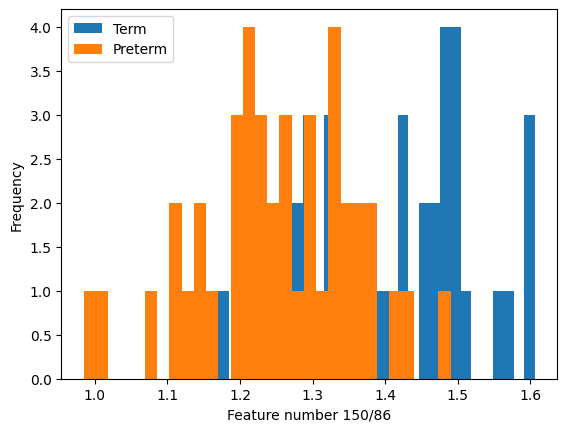

In [5]:
y_train=np.expand_dims(y_train, axis=0)
y_test = np.expand_dims(y_test, axis=0)
feature = 150
plt.hist(X_train[feature, y_train[0]==0],bins = 30)
plt.hist(X_train[feature, y_train[0]==1], bins=30)
plt.xlabel('Feature number {}/86'.format(feature))
plt.ylabel('Frequency')
plt.legend(['Term','Preterm']);

In [6]:
X_train = X_train.T
y_train = y_train.T
y_test = y_test.T
print(y_train.shape)

(80, 1)


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data only, then transform both
# We assume X_train is shape (80, 300)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Defining a class MLP which takes 300 of our features as input. it has  3 hidden layers which is then passed to a sigmoid function, between the layers is a relu activation function.

In [8]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP,self).__init__()
        self.fc1 = nn.Linear(300,100)
        self.fc2 = nn.Linear(100,100)
        self.fc3 = nn.Linear(100,100)
        self.fc4 = nn.Linear(100,100)
        self.fc5 = nn.Linear(100,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = x.float()
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = self.fc5(x)
        x= self.sigmoid(x)
        return x


model = MLP()

Defining the optimiser (SGD) and the loss function (BCELoss)

In [9]:

optimizer = torch.optim.SGD(model.parameters(),lr = 0.001, momentum = 0.9)
loss_function = torch.nn.BCELoss()

packaging the train and test data into tensordatasets and using Dataloader to batch and shuffle the dataset

In [10]:
dataset_tensor_train = torch.utils.data.TensorDataset(torch.tensor(X_train,dtype=torch.float32),torch.tensor(y_train,dtype=torch.float32))
dataset_tensor_test = torch.utils.data.TensorDataset(torch.tensor(X_test,dtype=torch.float32),torch.tensor(y_test,dtype=torch.float32))
train_dataloader = torch.utils.data.DataLoader(dataset_tensor_train, batch_size = 64, shuffle = True)
test_dataloader = torch.utils.data.DataLoader(dataset_tensor_test, batch_size = 64, shuffle = True)

Training function

In [11]:
def train(epoch,log_interval = 200):
    model.train()
    for batch_number, (input_number,labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        output = model(input_number)
        loss = loss_function(output,labels)
        loss.backward()
        optimizer.step()
        if batch_number % log_interval == 0:
            print("Train Epoch: {} Loss: {}  ".format(epoch,loss.item()))


Validation Function

In [12]:
def validation(loss_number, accuracy_number):
    model.eval()
    correct = 0
    validation_loss = 0
    with torch.no_grad():
        for input_number, labels in test_dataloader:
            output = model(input_number)
            loss = loss_function(output,labels)
            validation_loss += loss.item() * input_number.size(0)
            pred = (output>0.5).float()
            correct += pred.eq(labels.data).sum().item()

    validation_loss = validation_loss / len(test_dataloader.dataset)
    loss_number.append(validation_loss)
    accuracy = 100 * correct/ len(test_dataloader.dataset)
    accuracy_number.append(accuracy)
    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format( validation_loss, correct, len(test_dataloader.dataset), accuracy))


Training the model and validating it, printing the result

In [13]:
epoch = 50
loss_num = []
accuracy_num = []
for epoch in range(1,epoch+1):
    train(epoch)
    validation(loss_num, accuracy_num)


Train Epoch: 1 Loss: 0.6923507452011108  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 2 Loss: 0.6935902237892151  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 3 Loss: 0.6963688135147095  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 4 Loss: 0.6932265758514404  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 5 Loss: 0.6946011781692505  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 6 Loss: 0.6933885216712952  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 7 Loss: 0.6959872245788574  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 8 Loss: 0.6923283934593201  

Validation set: Average loss: 0.6905, Accuracy: 12/21 (57%)

Train Epoch: 9 Loss: 0.6946771740913391  

Validation set: Average loss: 0.6904, Accuracy: 12/21 (57%)

Train Epoch: 10 Loss: 0.6923366189002991  

Validation set: Aver

Plotting the validation loss and accuracy with each epoch

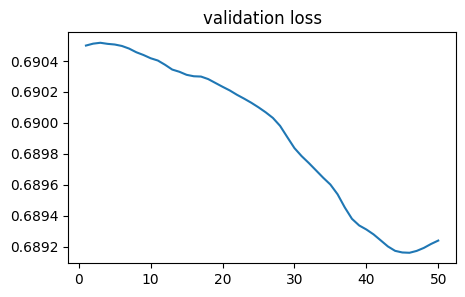

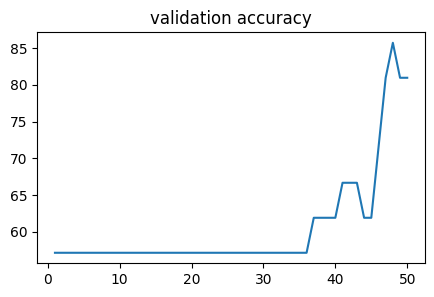

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epoch+1), loss_num)
plt.title('validation loss')

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epoch+1), accuracy_num)
plt.title('validation accuracy');